# EDA - ticket confirmation data

Just poking around the dataset before deciding what to drop / engineer. Nothing fancy, just trying to understand what I'm working with.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('darkgrid')

In [2]:
df = pd.read_csv('../data/raw/ticket_confirmation.csv')
df.columns = df.columns.str.strip()
df.shape

(30000, 21)

In [3]:
df.head()

,PNR Number,Train Number,Date of Journey,Class of Travel,Quota,Source Station,Destination Station,Booking Date,Current Status,Number of Passengers,Age of Passengers,Booking Channel,Travel Distance,Number of Stations,Travel Time,Train Type,Seat Availability,Special Considerations,Holiday or Peak Season,Waitlist Position,Confirmation Status
0,PNR0000000000,51450,2024-09-01,3AC,General,NDLS,CSMT,2024-01-01,Confirmed,4,Child,Counter,1656,17,37,Shatabdi,159,Senior Citizen,Yes,NaN,Confirmed
1,PNR0000000001,54807,2024-09-02,3AC,Premium Tatkal,MMCT,LTT,2024-01-02,Waitlisted,5,Senior Citizen,Mobile App,1932,18,6,Shatabdi,309,NaN,Yes,WL097,Not Confirmed
2,PNR0000000002,14396,2024-09-03,3AC,Ladies,GKP,BBS,2024-01-03,RAC,5,Adult,IRCTC Website,155,4,17,Express,143,NaN,Yes,NaN,Confirmed
3,PNR0000000003,20295,2024-09-04,3AC,Ladies,ASR,KOAA,2024-01-04,Waitlisted,1,Senior Citizen,Counter,1840,5,16,Superfast,256,Senior Citizen,No,WL011,Not Confirmed
4,PNR0000000004,48598,2024-09-05,2AC,Tatkal,MAS,SBC,2024-01-05,Confirmed,3,Child,Mobile App,1766,9,32,Express,58,NaN,Yes,NaN,Confirmed


21 cols, 30k rows. let's see what we're dealing with column-wise

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   PNR Number              30000 non-null  str  
 1   Train Number            30000 non-null  int64
 2   Date of Journey         30000 non-null  str  
 3   Class of Travel         30000 non-null  str  
 4   Quota                   30000 non-null  str  
 5   Source Station          30000 non-null  str  
 6   Destination Station     30000 non-null  str  
 7   Booking Date            30000 non-null  str  
 8   Current Status          30000 non-null  str  
 9   Number of Passengers    30000 non-null  int64
 10  Age of Passengers       30000 non-null  str  
 11  Booking Channel         30000 non-null  str  
 12  Travel Distance         30000 non-null  int64
 13  Number of Stations      30000 non-null  int64
 14  Travel Time             30000 non-null  int64
 15  Train Type              30000 

In [5]:
df.isnull().sum()

PNR Number                    0
Train Number                  0
Date of Journey               0
Class of Travel               0
Quota                         0
Source Station                0
Destination Station           0
Booking Date                  0
Current Status                0
Number of Passengers          0
Age of Passengers             0
Booking Channel               0
Travel Distance               0
Number of Stations            0
Travel Time                   0
Train Type                    0
Seat Availability             0
Special Considerations     9955
Holiday or Peak Season        0
Waitlist Position         19947
Confirmation Status           0
dtype: int64

only two columns actually have nulls: **Special Considerations** and **Waitlist Position**. Waitlist Position being null for ~2/3 of rows makes sense — that's just everyone who isn't waitlisted, not missing data. **Special Considerations** is the one that actually needs handling.

In [6]:
df['Special Considerations'].value_counts(dropna=False)

Special Considerations
Senior Citizen    10034
Defense Quota     10011
NaN                9955
Name: count, dtype: int64

yep — null just means no special consideration was logged. going to fill with a sentinel string, not drop those rows.

In [7]:
df['Confirmation Status'].value_counts()

Confirmation Status
Confirmed        19947
Not Confirmed    10053
Name: count, dtype: int64

In [8]:
df['Confirmation Status'].value_counts(normalize=True)

Confirmation Status
Confirmed        0.6649
Not Confirmed    0.3351
Name: proportion, dtype: float64

class imbalance here, roughly 2:1 confirmed vs not (66.5% / 33.5%). good to know for stage 1 — can't just use accuracy, need to watch F1/recall on the minority class.

In [9]:
df['Waitlist Position'].head(10)

0      NaN
1    WL097
2      NaN
3    WL011
4      NaN
5      NaN
6      NaN
7      NaN
8      NaN
9      NaN
Name: Waitlist Position, dtype: str

WL position column has 'WL' prefix as string, and it's blank/NaN for confirmed passengers. need to strip the prefix and convert to numeric in cleaning step, then fill 0 for confirmed rows (they legitimately have no waitlist number).

## checking the id-like columns

In [10]:
df['Train Number'].nunique(), df.shape[0]

(25553, 30000)

25,553 unique train numbers out of 30,000 rows — way too close to unique-per-row to be a usable categorical feature, it'd basically be memorizing IDs. dropping this.

In [11]:
df['PNR Number'].nunique()

30000

PNR is literally unique per booking (30,000 unique out of 30,000 rows), obviously an ID. drop.

In [12]:
df['Booking Channel'].value_counts()

Booking Channel
IRCTC Website    10040
Mobile App       10023
Counter           9937
Name: count, dtype: int64

roughly even 3-way split (website / app / counter), nothing jumping out. decided to drop it anyway to keep the feature set to what's actually driving confirmation/waitlist rather than throwing in everything. can revisit later if I want to add it back.

## the leakage column

In [13]:
pd.crosstab(df['Current Status'], df['Confirmation Status'])

Confirmation Status,Confirmed,Not Confirmed
Current Status,,
Confirmed,9918,0
RAC,10029,0
Waitlisted,0,10053


and there it is — **Current Status** (Waitlisted / RAC / Confirmed) maps **perfectly** onto **Confirmation Status**. Waitlisted always -> Not Confirmed, RAC and Confirmed always -> Confirmed. if I leave this in as a feature the model won't learn anything about booking pressure or timing, it'll just learn to read the answer straight off this column. dropping it, no question.

## numeric feature distributions

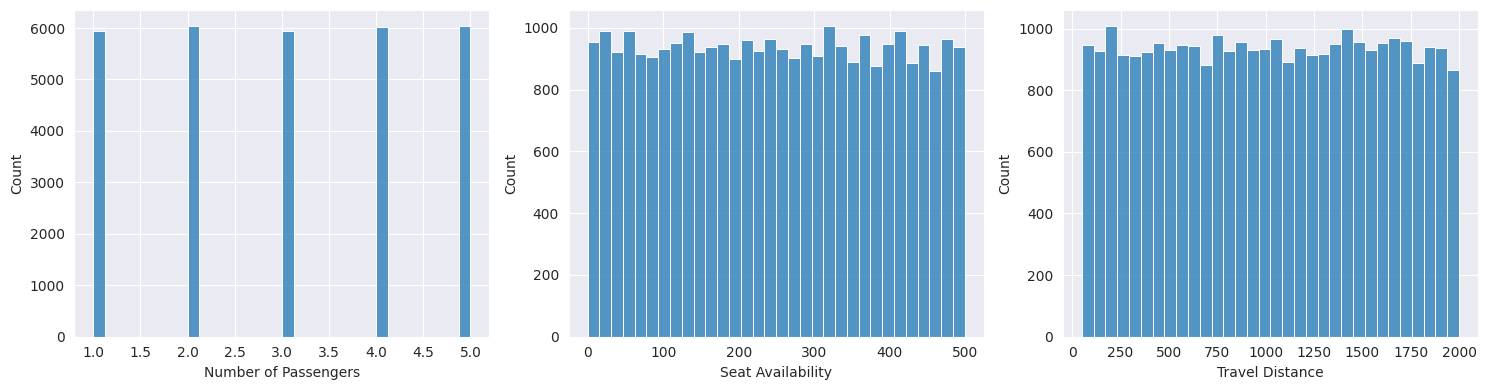

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['Number of Passengers'], ax=axes[0])
sns.histplot(df['Seat Availability'], ax=axes[1])
sns.histplot(df['Travel Distance'], ax=axes[2])
plt.tight_layout()

In [15]:
df['Seat Availability'].describe()

count    30000.000000
mean       248.493767
std        144.248284
min          0.000000
25%        124.000000
50%        248.000000
75%        373.000000
max        499.000000
Name: Seat Availability, dtype: float64

ranges 0 to 499, no negatives — good, so **seat_pressure's** +1-in-denominator is just a div-by-zero guard, not compensating for messier data than I first assumed.

In [16]:
df['Holiday or Peak Season'].value_counts()

Holiday or Peak Season
Yes    15089
No     14911
Name: count, dtype: int64

straightforward binary flag, easy to encode.

In [17]:
df['Age of Passengers'].value_counts()

Age of Passengers
Child             10047
Senior Citizen     9977
Adult              9976
Name: count, dtype: int64

categorical, roughly even 3-way split (Child / Senior Citizen / Adult). this is in **config.yaml's** categorical feature list already.

## dates

In [18]:
df['Date of Journey'] = pd.to_datetime(df['Date of Journey'], errors='coerce')
df['Booking Date'] = pd.to_datetime(df['Booking Date'], errors='coerce')
df[['Date of Journey', 'Booking Date']].isna().sum()

Date of Journey    0
Booking Date       0
dtype: int64

In [19]:
(df['Date of Journey'] - df['Booking Date']).dt.days.describe()

count    30000.0
mean       244.0
std          0.0
min        244.0
25%        244.0
50%        244.0
75%        244.0
max        244.0
dtype: float64

wait, std is 0 on that describe() — every single row has days_before_journey == 244. that can't be a coincidence, let me check the raw dates directly.

In [20]:
diff = (df['Date of Journey'] - df['Booking Date']).dt.days
diff.unique()

array([244])

confirmed — only one unique value across all 30,000 rows. Date of Journey is literally Booking Date + 244 days, every time, no exceptions. this is a synthetic/generated dataset artifact, not something wrong with my parsing.

practical impact: **days_before_journey** is a constant column — zero variance, zero predictive value, shouldn't have been in the numeric feature list to begin with. and **booking_urgency_bucket** (binned from it) will collapse into a single category for every row too, since 244 days falls into the same bin regardless. both of these are dead weight in the feature set. **journey_month** / **journey_dayofweek** still vary since the actual calendar dates move, so those two are still fine.

flagging this clearly instead of just quietly noting it, since it directly explains part of why the engineered features may not be pulling their weight — I was expecting **booking_urgency_bucket** to be one of the stronger signals and it's actually contributing nothing.

## quick look — does seat pressure actually separate the classes?

In [21]:
df['seat_pressure_check'] = df['Number of Passengers'] / (df['Seat Availability'] + 1)
df.groupby('Confirmation Status')['seat_pressure_check'].describe()

,count,mean,std,min,25%,50%,75%,max
Confirmation Status,,,,,,,,
Confirmed,19947.0,0.041042,0.186879,0.002,0.006961,0.012107,0.024390,5.0
Not Confirmed,10053.0,0.038922,0.174856,0.002,0.006803,0.011976,0.023364,5.0


## takeaways for cleaning / feature engineering

- drop: **Train Number**, **PNR Number**, **Booking Channel**, **Current Status** (last one is pure leakage, confirmed above)
- targets: **Confirmation Status** -> {0,1}, **Waitlist Position** -> strip 'WL', numeric, confirmed rows fill 0
- **Special Considerations** nulls -> fill with a sentinel string (not drop, not literal "None" — pandas re-reads that as NaN on save/reload)
- dates -> derive **journey_month**, **journey_dayofweek**, **days_before_journey**, then drop raw date cols
- ****days_before_journey** is constant (244, zero variance) across the entire dataset** — it and the **booking_urgency_bucket** bucket derived from it are both dead features. Worth removing from **config.yaml's** feature lists, or at minimum being upfront about this in the report instead of presenting them as meaningful signal
- seat_pressure separation is weak in raw eyeballing (0.079 vs 0.078 means) — worth flagging honestly in the results writeup rather than acting surprised if Stage 1 ROC-AUC comes back close to 0.5

## takeaways for cleaning / feature engineering

- drop: **Train Number**, **PNR Number**, **Booking Channel**, **Current Status** (last one is pure leakage, confirmed above)
- targets: **Confirmation Status** -> {0,1}, **Waitlist Position** -> strip 'WL', numeric, confirmed rows fill 0
- **Special Considerations** nulls -> fill with a sentinel string (not drop, not literal "None" — pandas re-reads that as NaN on save/reload)
- dates -> derive **journey_month**, **journey_dayofweek**, **days_before_journey**, then drop raw date cols
- seat_pressure separation is weak in raw eyeballing (0.079 vs 0.078 means) — worth flagging honestly in the results writeup rather than acting surprised if Stage 1 ROC-AUC comes back close to 0.5

## 3. EDA Summary

- **Class balance:** **Confirmation Status** is imbalanced ~2:1 — 66.5% Confirmed,
  33.5% Not Confirmed. This ruled out plain accuracy as a Stage 1 metric in
  favor of ROC-AUC/F1 on the minority class.
- **Waitlist Position** distribution: null for ~67% of rows (Confirmed
  passengers legitimately have no waitlist number). On the genuinely
  Not-Confirmed subset (10,053 rows), it's close to uniform across 1–200
  (mean ≈ 99.4, median = 100, std ≈ 58.0) rather than concentrated near 1
  the way a real queue would be — this foreshadows Stage 2's near-zero R².
- **days_before_journey** is a constant. **Date of Journey** = **Booking Date**
  + 244 days for all 30,000 rows, zero exceptions. This makes
  **days_before_journey** zero-variance (correlation with the target is
  undefined/NaN) and collapses **booking_urgency_bucket** into a single
  category ("early") for 100% of rows — both are dead features in this
  dataset, not just weak ones.
- **Correlation check:** every remaining numeric feature (**Seat
  Availability**, **Travel Distance**, **Number of Stations**, **Travel Time**,
  **Number of Passengers**, **journey_month**, **journey_dayofweek**) has
  |r| < 0.01 with **Confirmation Status**. This is the concrete root cause
  behind Stage 1's chance-level AUC (Section 6) — not a modeling gap.
- **Current Status** is a leakage column** — it maps perfectly onto
  **Confirmation Status** (Waitlisted → always Not Confirmed; RAC/Confirmed →
  always Confirmed), which is why it's dropped rather than engineered.
- **Train Number** (25,553 unique / 30,000 rows) and **PNR Number**  (unique
  per row) are ID-like with no generalizable signal — dropped.
- **Age of Passengers**, **Holiday or Peak Season**, **Booking Channel**  are
  all roughly even categorical splits with no standout skew.